In [16]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import yaml
import os
import subprocess
import shutil

In [15]:
import h5py
import numpy as np

filename = "../psls-1.9/grid_plato.hdf5"

def get_data(obj, field):
    """Safe helper to get data whether 'obj' is a Group or a Compound Dataset."""
    if isinstance(obj, h5py.Dataset): # It's a table/compound type
        return obj[field]
    else: # It's a group/folder
        return obj[field][:]

with h5py.File(filename, 'r') as f:
    print(f"{'Track Name':<25} | {'Mass':<8} | {'Teff Range (K)':<18} | {'logg Range'}")
    print("-" * 75)
    
    for key in f.keys():
        try:
            group = f[key]
            # Handle the 'global' data
            g_data = group['global']
            
            # Get values using the helper
            teffs = get_data(g_data, 'teff')
            loggs = get_data(g_data, 'logg')
            
            # Get mass - usually in parameters or global
            try:
                mass = float(group['parameters/mass0'][()])
            except:
                mass = float(get_data(g_data, 'mass')[0])
                
            t_min, t_max = teffs.min(), teffs.max()
            g_min, g_max = loggs.min(), loggs.max()
            
            print(f"{key:<25} | {mass:<8.3f} | {t_min:>6.1f} - {t_max:<6.1f} | {g_min:.2f} - {g_max:.2f}")
            
        except Exception as e:
            # Skip metadata or non-stellar groups
            continue

Track Name                | Mass     | Teff Range (K)     | logg Range
---------------------------------------------------------------------------
grid_v0.1_ov0_001000      | 1.050    | 4323.4 - 5940.4 | 3.44 - 4.51
grid_v0.1_ov0_001002      | 0.975    | 4305.9 - 5903.4 | 3.45 - 4.53
grid_v0.1_ov0_001003      | 1.012    | 4216.3 - 5865.8 | 3.42 - 4.54
grid_v0.1_ov0_001006      | 0.938    | 4041.3 - 5639.4 | 3.40 - 4.57
grid_v0.1_ov0_001007      | 0.956    | 4208.2 - 5839.4 | 3.44 - 4.57
grid_v0.1_ov0_001008      | 1.106    | 4343.6 - 6120.8 | 3.42 - 4.46
grid_v0.1_ov0_001010      | 1.031    | 4420.1 - 6183.5 | 3.46 - 4.50
grid_v0.1_ov0_001012      | 1.144    | 4487.2 - 6337.7 | 3.45 - 4.43
grid_v0.1_ov0_001013      | 1.069    | 4428.6 - 6193.8 | 3.46 - 4.49
grid_v0.1_ov0_001014      | 0.919    | 4104.5 - 5742.6 | 3.41 - 4.57
grid_v0.1_ov0_001015      | 0.928    | 4016.1 - 5592.3 | 3.40 - 4.58
grid_v0.1_ov0_001018      | 1.003    | 4249.3 - 5939.0 | 3.43 - 4.53
grid_v0.1_ov0_001020     

/var/folders/dt/hdl85s4s5jng99gtl5y_bxnr0000gn/T/ipykernel_59726/623214407.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(group['parameters/mass0'][()])


grid_v0.1_ov0_001140      | 1.147    | 4432.4 - 6279.5 | 3.43 - 4.43
grid_v0.1_ov0_001142      | 0.922    | 4141.6 - 5768.4 | 3.43 - 4.58
grid_v0.1_ov0_001144      | 1.082    | 4368.0 - 6129.8 | 3.44 - 4.48
grid_v0.1_ov0_001145      | 1.157    | 4369.0 - 6135.3 | 3.43 - 4.46
grid_v0.1_ov0_001147      | 1.044    | 4236.7 - 5896.1 | 3.42 - 4.53
grid_v0.1_ov0_001148      | 1.194    | 4617.3 - 6611.0 | 3.47 - 4.39


In [63]:
# --- CONFIGURATION ---
BASE_YAML_PATH = "../psls-1.9/examples/0012069449.yaml"  # Path to your existing base file
OUTPUT_ROOT = "psls_results"
PSLS_EXEC = "psls.py"

# Define the temperatures you want to test from your grid
# Based on your HDF5 exploration, these are valid G-star temps
test_scenarios = [
    # Adjusted logg slightly higher to stay in 'safe' territory
    {"teff": 5700.0, "logg": 4.30, "id": 1001, "label": "old_g_star"}, 
    {"teff": 5778.0, "logg": 4.44, "id": 1002, "label": "sun_like"},
    {"teff": 5900.0, "logg": 4.50, "id": 1003, "label": "young_g_star"}
]

In [64]:
def run_simulation(scenario):
    label = scenario['label']
    teff = scenario['teff']
    logg = scenario['logg']
    star_id = scenario['id'] # Must be an integer
    
    run_dir = os.path.join(OUTPUT_ROOT, label)
    os.makedirs(run_dir, exist_ok=True)
    
    with open(BASE_YAML_PATH, 'r') as f:
        config = yaml.safe_load(f)
    
    # UPDATE: Keep ID as integer to satisfy psls.py line 682
    config['Star']['Teff'] = teff
    config['Star']['Logg'] = logg
    config['Star']['ID'] = star_id 
    config['Observation']['MasterSeed'] = int(1)
    
    temp_yaml_name = f"config_{label}.yaml"
    temp_yaml_path = os.path.join(run_dir, temp_yaml_name)
    with open(temp_yaml_path, 'w') as f:
        yaml.dump(config, f)
    
    print(f"--- Starting Simulation: {label} (ID: {star_id}, Teff: {teff}) ---")
    
    try:
        # Running with cwd=run_dir ensures outputs go into the labeled folder
        subprocess.run([PSLS_EXEC, temp_yaml_name], cwd=run_dir, check=True)
        print(f"Successfully generated light curve for {label}\n")
    except subprocess.CalledProcessError as e:
        print(f"Error running PSLS for {label}: {e}\n")

for scenario in test_scenarios:
    run_simulation(scenario)

--- Starting Simulation: old_g_star (ID: 1001, Teff: 5700.0) ---
Successfully generated light curve for old_g_star

--- Starting Simulation: sun_like (ID: 1002, Teff: 5778.0) ---
Successfully generated light curve for sun_like

--- Starting Simulation: young_g_star (ID: 1003, Teff: 5900.0) ---
Successfully generated light curve for young_g_star



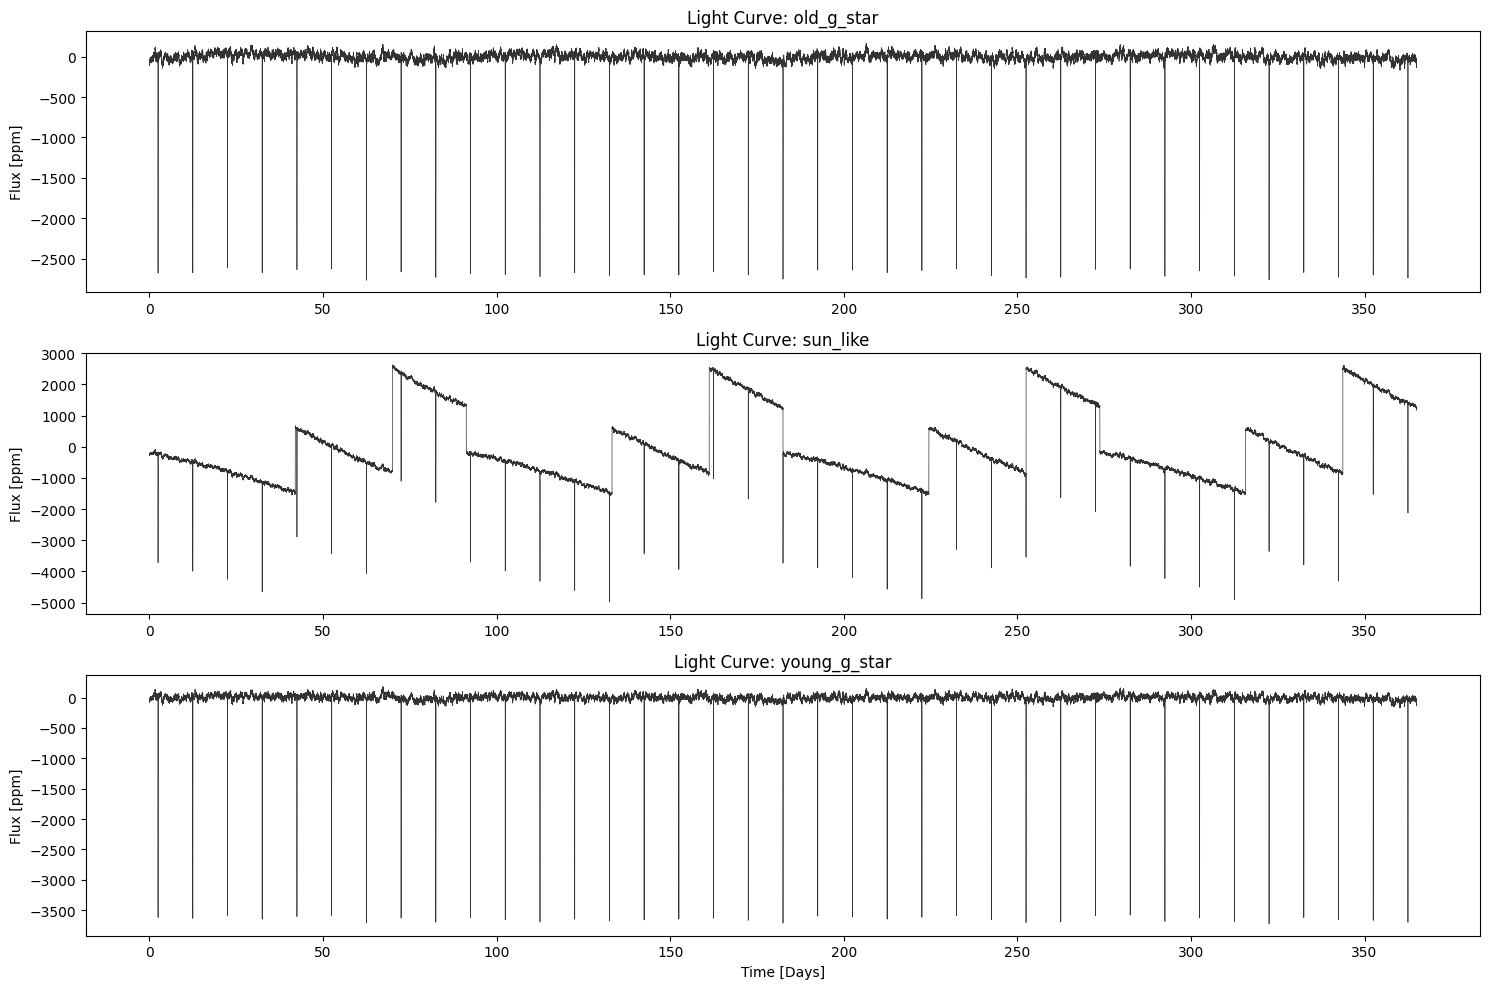

In [65]:
results_path = "psls_results"
scenarios = [
    {"label": "old_g_star",   "id": "0000001001"},
    {"label": "sun_like",     "id": "0000001002"},
    {"label": "young_g_star", "id": "0000001003"}
]

plt.figure(figsize=(15, 10))

for i, sc in enumerate(scenarios):
    file_path = os.path.join(results_path, sc['label'], f"{sc['id']}.dat")
    
    # Use genfromtxt which is better for files with mixed headers/comments
    # invalid_raise=False skips any rows that aren't numeric
    data = np.genfromtxt(file_path, comments='#', invalid_raise=False)
    
    if data.size == 0:
        print(f"Warning: No data found in {file_path}")
        continue

    time_days = data[:, 0] / 86400  # Convert seconds to days
    flux = data[:, 1]
    
    ax = plt.subplot(3, 1, i+1)
    ax.plot(time_days, flux, lw=0.5, color='black', alpha=0.8)
    
    ax.set_title(f"Light Curve: {sc['label']}", fontsize=12)
    ax.set_ylabel("Flux [ppm]")
    if i == 2:
        ax.set_xlabel("Time [Days]")

plt.tight_layout()
plt.show()

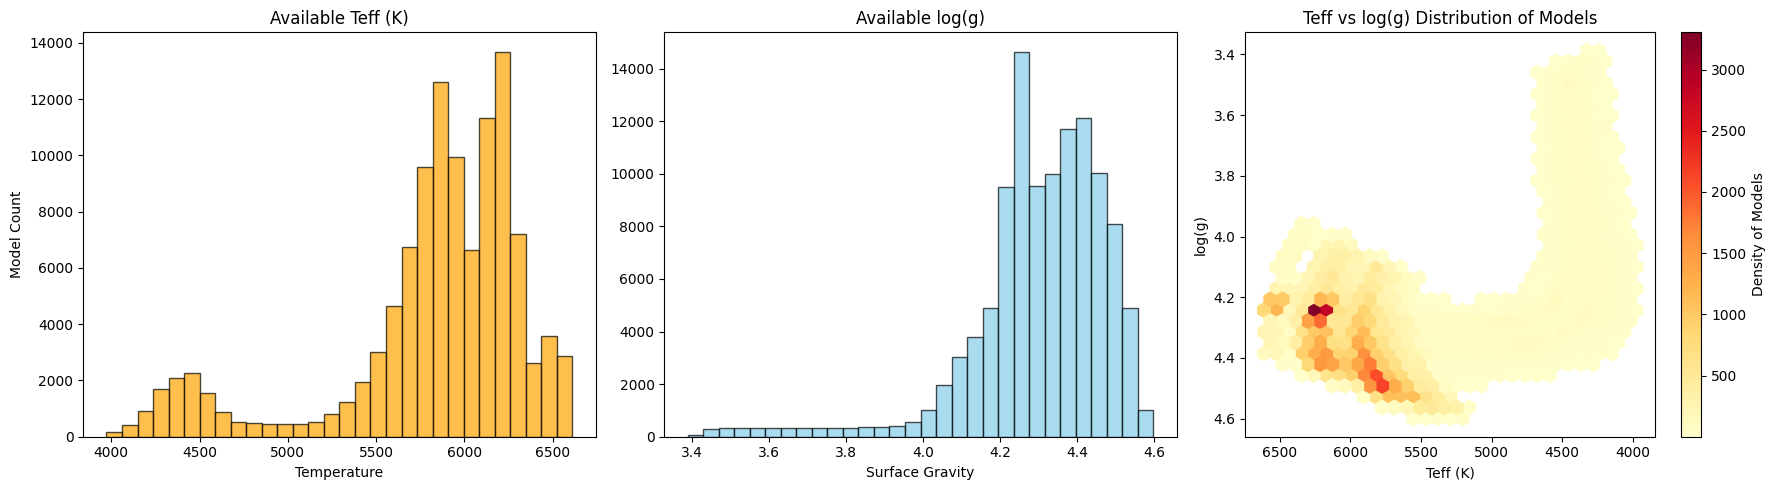

Teff Range: 3973.2 - 6611.0 K
Logg Range: 3.39 - 4.60


In [54]:
filename = "../psls-1.9/grid_plato.hdf5"

all_teff = []
all_logg = []

with h5py.File(filename, 'r') as f:
    # Loop through every stellar track in the file
    for key in f.keys():
        if 'grid' in key:
            try:
                # Extract the 515 models for this specific mass
                t = f[key]['global/teff'][:]
                g = f[key]['global/logg'][:]
                
                all_teff.extend(t)
                all_logg.extend(g)
            except KeyError:
                continue

# Convert to numpy for easy stats
all_teff = np.array(all_teff)
all_logg = np.array(all_logg)

# --- PLOTTING ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Teff Histogram
ax[0].hist(all_teff, bins=30, color='orange', edgecolor='black', alpha=0.7)
ax[0].set_title('Available Teff (K)')
ax[0].set_xlabel('Temperature')
ax[0].set_ylabel('Model Count')

# 2. Logg Histogram
ax[1].hist(all_logg, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax[1].set_title('Available log(g)')
ax[1].set_xlabel('Surface Gravity')

# 3. 2D Distribution (The "Kiel Diagram")
# This shows you the actual "Physical Space" you can sample from
hb = ax[2].hexbin(all_teff, all_logg, gridsize=30, cmap='YlOrRd', mincnt=1)
ax[2].set_title('Teff vs log(g) Distribution of Models')
ax[2].set_xlabel('Teff (K)')
ax[2].set_ylabel('log(g)')
ax[2].invert_xaxis() # Stars are hotter to the left
ax[2].invert_yaxis() # Gravity is higher (dwarfs) at the top
plt.colorbar(hb, ax=ax[2], label='Density of Models')

plt.tight_layout()
plt.show()

#print(f"Total available models to sample: {len(all_teff)}")
print(f"Teff Range: {all_teff.min():.1f} - {all_teff.max():.1f} K")
print(f"Logg Range: {all_logg.min():.2f} - {all_logg.max():.2f}")